In [12]:
from oggm.shop import bedtopo
from oggm import workflow
import xarray as xr  # Import xarray 
import matplotlib.pyplot as plt


In [2]:
from oggm import cfg, utils, workflow, tasks, graphics
cfg.initialize(logging_level='WARNING')

2025-01-08 12:13:42: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-08 12:13:42: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-08 12:13:42: oggm.cfg: Multiprocessing: using all available processors (N=16)


In [3]:
# Local working directory (where OGGM will write its output)
# WORKING_DIR = utils.gettempdir('OGGM_distr4')
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap /OGGM/data'

In [4]:
rgi_ids = ['RGI60-14.02192']  # Fieschergletscher

In [5]:
# The RGI version to use
# Size of the map around the glacier.
prepro_border = 80
# Degree of processing level. This is OGGM specific and for the shop 1 is the one you want
from_prepro_level = 3
# URL of the preprocessed gdirs
# we use elevation bands flowlines here
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdirs = workflow.init_glacier_directories(rgi_ids,
                                          from_prepro_level=from_prepro_level,
                                          prepro_base_url=base_url,
                                          prepro_border=prepro_border)

2025-01-08 12:13:43: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-08 12:13:43: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [6]:
gdir = gdirs[0]

In [7]:
from oggm.shop import bedtopo

In [8]:
workflow.execute_entity_task(bedtopo.add_consensus_thickness, gdirs);

2025-01-08 12:13:43: oggm.workflow: Execute entity tasks [add_consensus_thickness] on 1 glaciers


In [9]:

with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()


In [10]:
# plot the salem map background, make countries in grey
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data);

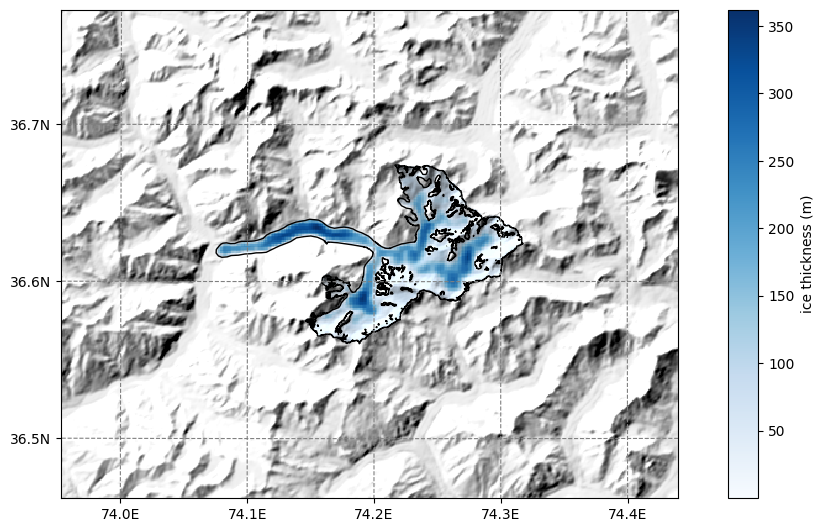

In [13]:
f, ax = plt.subplots(figsize=(9, 9))
smap.set_data(ds.consensus_ice_thickness)
smap.set_cmap('Blues')
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label='ice thickness (m)');

OGGM-Shop: velocities

In [14]:
# attention downloads data!!!
from oggm.shop import millan22
workflow.execute_entity_task(millan22.velocity_to_gdir, gdirs);

2025-01-08 12:19:05: oggm.workflow: Execute entity tasks [velocity_to_gdir] on 1 glaciers
